<a href="https://colab.research.google.com/github/rd-gabriela/IC-percepcao-temporal/blob/main/Taxa_VA_ModeloContaTiques(github).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import truncnorm

In [19]:
#Repetições
repeticoes = 1000
t = 1000

#Futura matriz para armazenar os tempos dos tiques
valores = []
#Médias e dps
medias = []
dps = []

#Parâmetros da distribuição da taxa
loc = 1
scale = 0.1
a = (0 - loc) / scale                     #calcula a quantos desvios padroes a nova media está da media "padrao" 0 da truncnorm
b = np.inf

#Função para calcular o valor do tempo depois de um certo num de tiques -> supondo que esse numero de tiques aconteça em intervalo aprendido anteriormente
def calcular_tiques(erro, h, n_tiques):
  soma_erros = erro.sum()
  tique_n = (n_tiques * h) + soma_erros
  return tique_n

#Variando o número de tiques (dado por 'k')
for k in range(1, t+1):
    #A cada "estimativa", uma nova taxa é sorteada de uma normal de média 1 e desvio padrão 0.1, truncada para valores negativos

    taxa = truncnorm.rvs(a, b, loc=loc, scale=scale, size=repeticoes)

    #Armazena o valor do tempo do tique_n para cada repetição
    linha_k = []

    for i in range(repeticoes):
      h = 1 / taxa[i]
      erro = np.random.normal(loc=0, scale=0.2, size=k)
      linha_k.append(calcular_tiques(erro, h, k))

    #Guarda a linha com os valores dos tempos de todas as repetições para o mesmo valor de tique
    valores.append(linha_k)

    #Calcula a média e dp para todas as repetições de um mesmo valor de tiques
    medias.append(np.mean(linha_k))
    dps.append(np.std(linha_k))

valores = np.array(valores)

#Calcular o coeficiente de variação
cv = []

for i in range(len(medias)):
  cv += [dps[i] / medias[i]]


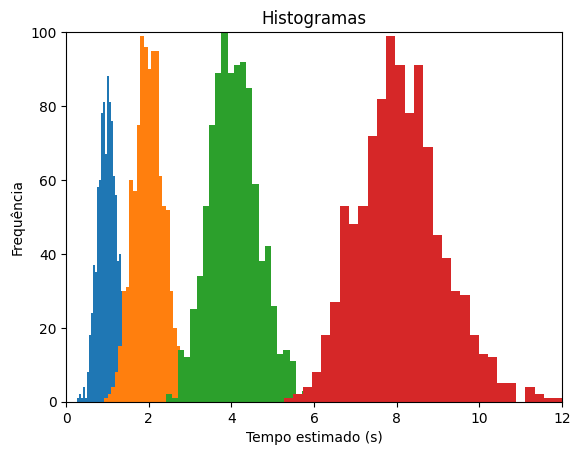

In [21]:
#Histogramas
for k in [1, 2, 4, 8]:
  plt.hist(valores[k-1, :], bins=30)

#Manter mesma escala
plt.xlim(0, 12)
plt.ylim(0, 100)
plt.xlabel('Tempo estimado (s)')
plt.ylabel('Frequência')
plt.title('Histogramas')

plt.show()

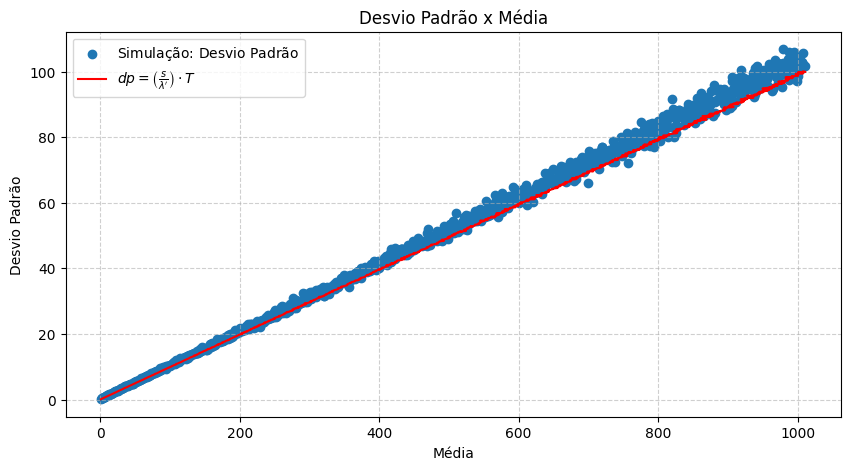

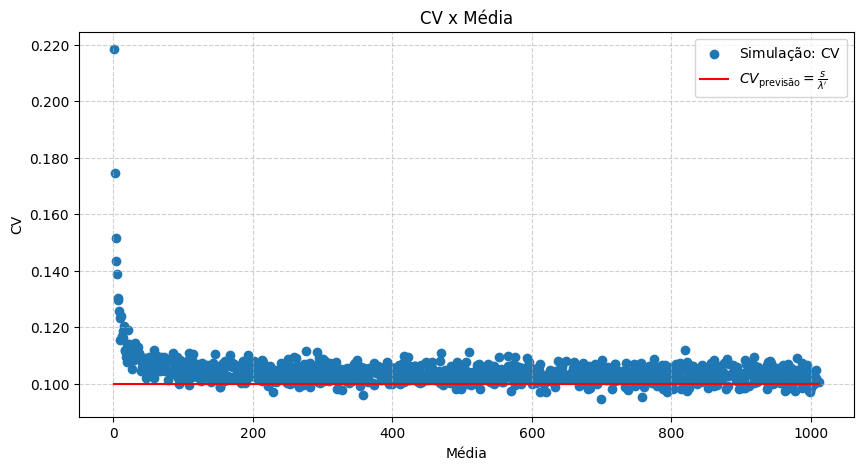

In [13]:
#Gráfico de dp por média - Simulação
plt.figure(figsize=(10, 5))
plt.title("Desvio Padrão x Média")
plt.xlabel("Média")
plt.ylabel("Desvio Padrão")
plt.scatter(medias, dps, label=r'Simulação: $\text{Desvio Padrão}$')

#Previsão Teoria (acúmulo de tiques que disparam a uma taxa que segue uma distribuição normal)
#<T'> = T e dp = T x (1 / taxa') x s -> taxa'= valor esperado da distribuição da taxa de emissão de tiques; s = dp da distribuição da taxa de emissão de tiques
x = medias
y_previsao = []
dp = 0

for i in range(1, t+1):
  dp = i * (1 * 1) * 0.1
  y_previsao.append(dp)

plt.plot(x, y_previsao, color='r', label=r"$dp = \left( \frac{s}{\lambda'} \right) \cdot T $")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

#CV x Média - Simulação
plt.figure(figsize=(10, 5))
plt.title("CV x Média")
plt.xlabel("Média")
plt.ylabel("CV")
plt.scatter(medias, cv, label=r'Simulação: $\text{CV}$')

#Previsão Teoria (acúmulo de tiques que disparam a uma taxa que segue uma distribuição)
# CV = s / taxa'
x = medias
y_previsao_cv = [0.1 * 1] * len(x)

plt.plot(x, y_previsao_cv, color='r', label=r"$CV_{\text{previsão}} = \frac{s}{\lambda'}$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.3f}')

plt.show()